# Tutorial 2 — Calibrating the richness–mass relation by recycling cluster posteriors

In **Tutorial 1** the population was a mean + an intrinsic scatter. Here the population model is a full
**mass–observable relation (MOR)** — the **richness–mass relation** — and we infer its parameters by
**recycling** each cluster's weak-lensing (WL) mass posterior. This is exactly **cluster mass calibration**,
the step that turns cluster counts into a cosmology measurement.

It also teaches a subtle, important lesson: **recycling WL posteriors is not enough by itself.** To get the
relation right you must fold in the **halo mass function** (the mass prior) — otherwise you reproduce the
classic **Eddington bias**. We will see naive, flat-prior, and correct versions side by side, each with its
own figure.

> Setup: `pip install "numpy<2" emcee "matplotlib<3.9"`

In [1]:
import numpy as np
import emcee
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 12, "figure.figsize": (6, 4)})
np.random.seed(11)

def run_mcmc(log_post, start, n_walkers=16, n_burn=1500, n_steps=5000):
    # small reusable emcee wrapper -> flat samples
    n_dim = len(start); p0 = start + 0.03*np.random.randn(n_walkers, n_dim)
    s = emcee.EnsembleSampler(n_walkers, n_dim, log_post)
    st = s.run_mcmc(p0, n_burn, progress=False); s.reset(); s.run_mcmc(st, n_steps, progress=False)
    try: tau_ac = float(np.mean(s.get_autocorr_time(quiet=True)))
    except Exception: tau_ac = float("nan")
    ess = (n_walkers*n_steps/tau_ac) if tau_ac == tau_ac else float("nan")
    print("   acceptance=%.2f | autocorr ~%.0f steps | ~%.0f independent samples" % (s.acceptance_fraction.mean(), tau_ac, ess))
    return s.get_chain(flat=True)
print("emcee", emcee.__version__, "| numpy", np.__version__)

emcee 3.1.6 | numpy 1.26.4


## 1. The mass–observable relation (the richness–mass relation)

For optical clusters the observable is the **richness** $\lambda$ (number of member galaxies). The standard
form (e.g. **Murata et al. 2018**; **McClintock et al. 2019**) is a **power law in mass**, written
**log-normal in richness at fixed mass**:
$$\langle\ln\lambda\mid M\rangle \;=\; A \;+\; B\,\ln\!\big(M/M_{\rm piv}\big),\qquad
   \ln\lambda \mid M \sim \mathcal N\!\big(\langle\ln\lambda\mid M\rangle,\;\sigma_{\ln\lambda|M}^2\big).$$
- $A$ = **normalization** (amplitude), $B$ = **mass slope**, $\sigma_{\ln\lambda|M}$ = **intrinsic scatter**
  (the lognormal scatter of richness at fixed mass; Murata find $\sigma_{\ln\lambda|M}\approx0.25$–$0.46$).
- $M_{\rm piv}=3\times10^{14}\,h^{-1}M_\odot$ is the **pivot mass**.

These three numbers $\Lambda=(A,B,\sigma)$ are the **scaling-relation parameters** (the *hyper-parameters*) we
want to measure. Let $x\equiv\ln(M/M_{\rm piv})$ and $y\equiv\ln\lambda$, so the relation is the line
$y=A+Bx+\mathcal N(0,\sigma^2)$.

In [2]:
# TRUE scaling-relation parameters (our ground truth), near the Murata et al. 2018 values:
A_true, B_true, sigma_true = 3.20, 1.00, 0.35      # normalization, mass slope, intrinsic scatter (lognormal)

# The MASS DISTRIBUTION of the sample: the halo mass function folded through the (richness) selection.
# Real shape is a steeply FALLING, asymmetric function; here we use a Gaussian in x=ln(M/Mpiv) for clarity
# (this symmetric simplification under-states how directional the real Eddington bias is).
sigma_mass = 0.50            # spread of true log-masses in the sample (the mass-function/selection width)

# Per-cluster WEAK-LENSING mass uncertainty (individual-cluster WL masses are noisy).
sigma_WL = 0.40              # 1-sigma WL error on x = ln(M/Mpiv)

n_clusters = 120
print("TRUE hyper-parameters:  A=%.2f  B=%.2f  sigma_intr=%.2f" % (A_true, B_true, sigma_true))

TRUE hyper-parameters:  A=3.20  B=1.00  sigma_intr=0.35


## 2. Simulate a cluster sample (the generative model)

For each cluster: draw a true mass from the mass distribution, draw its richness from the relation (with
intrinsic scatter), then make a **noisy weak-lensing mass** measurement.

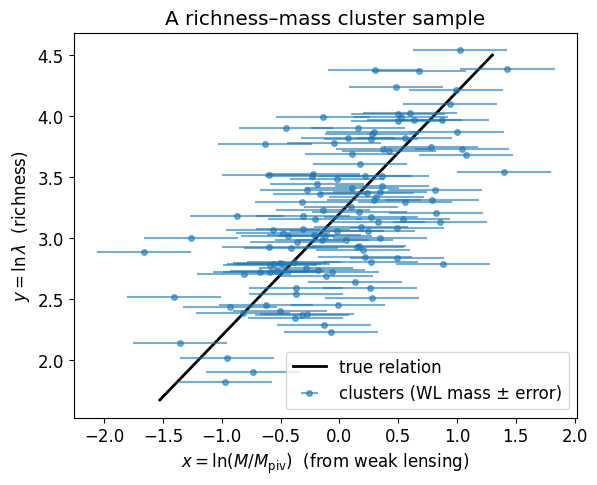

In [3]:
x_true = sigma_mass * np.random.randn(n_clusters)                              # true x = ln(M/Mpiv)
y_obs  = A_true + B_true*x_true + sigma_true*np.random.randn(n_clusters)        # observed ln(richness)
x_wl   = x_true + sigma_WL*np.random.randn(n_clusters)                          # WL point estimate of x

grid = np.linspace(x_true.min()-0.2, x_true.max()+0.2, 50)
plt.figure(figsize=(6.5, 5))
plt.plot(grid, A_true + B_true*grid, "k-", lw=2, label="true relation")
plt.errorbar(x_wl, y_obs, xerr=sigma_WL, fmt="o", ms=4, color="tab:blue", alpha=0.6, label="clusters (WL mass ± error)")
plt.xlabel(r"$x=\ln(M/M_{\rm piv})$  (from weak lensing)"); plt.ylabel(r"$y=\ln\lambda$  (richness)")
plt.title("A richness–mass cluster sample"); plt.legend(); plt.show()

## 3. The per-cluster WL mass posteriors (what we recycle)

A real WL pipeline outputs, per cluster, a **posterior on its mass** $p(x_j\mid d_j)$ — here
$\mathcal N(x_j^{\rm WL},\sigma_{\rm WL}^2)$ under a flat interim prior. We draw $S$ samples from each.
**These stand in for the samples a real pipeline saves per cluster.**

In [4]:
n_samples = 3000
wl_samples = x_wl[:, None] + sigma_WL*np.random.randn(n_clusters, n_samples)
print("wl_samples shape =", wl_samples.shape, " (clusters x posterior-samples)")

wl_samples shape = (120, 3000)  (clusters x posterior-samples)


## 4. Attempt 1 — fit the relation to the **point** WL masses → Eddington bias

Fitting a line to $(x_j^{\rm WL},y_j)$ by least squares is **biased**: because $x$ carries measurement
error, the slope is **attenuated** toward zero (regression dilution). In cluster cosmology this is the
**Eddington bias**. The attenuation factor is $\sigma_{\rm mass}^2/(\sigma_{\rm mass}^2+\sigma_{\rm WL}^2)$ —
note the denominator is the **observed** x-variance (signal + noise).

Attempt 1 (naive OLS):  A=3.18  B=0.61  sigma=0.450
expected attenuated slope = B*0.61 = 0.61   (true B=1.00)


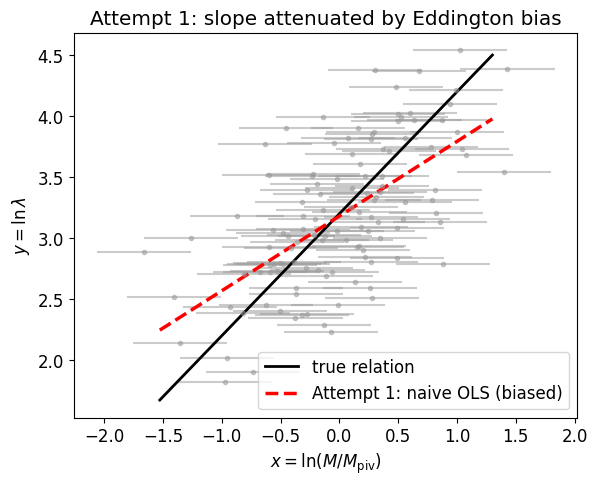

In [5]:
B_naive, A_naive = np.polyfit(x_wl, y_obs, 1)
sigma_naive = (y_obs - (A_naive + B_naive*x_wl)).std()
attn = sigma_mass**2 / (sigma_mass**2 + sigma_WL**2)
print("Attempt 1 (naive OLS):  A=%.2f  B=%.2f  sigma=%.3f" % (A_naive, B_naive, sigma_naive))
print("expected attenuated slope = B*%.2f = %.2f   (true B=%.2f)" % (attn, B_true*attn, B_true))

plt.figure(figsize=(6.5, 5))
plt.errorbar(x_wl, y_obs, xerr=sigma_WL, fmt="o", ms=3, color="0.6", alpha=0.5)
plt.plot(grid, A_true + B_true*grid, "k-", lw=2, label="true relation")
plt.plot(grid, A_naive + B_naive*grid, "r--", lw=2.5, label="Attempt 1: naive OLS (biased)")
plt.xlabel(r"$x=\ln(M/M_{\rm piv})$"); plt.ylabel(r"$y=\ln\lambda$")
plt.title("Attempt 1: slope attenuated by Eddington bias"); plt.legend(); plt.show()

## 5. Attempt 2 — recycle the posteriors with a **flat** mass prior (still biased!)

The hierarchical model: $x_j\sim p(x)$ (mass distribution), $y_j\mid x_j\sim\mathcal N(A+Bx_j,\sigma^2)$, WL
data $d_j\mid x_j$. The **hyper-posterior** marginalises each latent mass:
$$p(\Lambda\mid\{d_j,y_j\})\ \propto\ \pi(\Lambda)\prod_j\int p(d_j\mid x_j)\,p(y_j\mid x_j,\Lambda)\,p(x_j)\,dx_j .$$
**Recycling identity** with stored samples $x_j^{(s)}\sim p(x_j\mid d_j)\propto p(d_j\mid x_j)\pi_0(x_j)$:
$$\int p(d_j\mid x)p(y_j\mid x,\Lambda)p(x)\,dx\ \approx\ \frac{\mathcal Z_j}{S}\sum_s p\big(y_j\mid x_j^{(s)},\Lambda\big)\frac{p(x_j^{(s)})}{\pi_0(x_j^{(s)})}.$$
**Attempt 2 drops the weight $p(x)/\pi_0$** (pretends the mass prior is flat) and just averages
$\mathcal N(y_j;A+Bx_j^{(s)},\sigma^2)$ over the samples. *(In code we sample $\ln\sigma$ for positivity; the
`+log_s` term is the change-of-variables Jacobian — a flat prior on $\sigma$.)*

   acceptance=0.65 | autocorr ~41 steps | ~1938 independent samples
Attempt 2 (recycle, FLAT prior):  A=3.18  B=0.62  sigma=0.382   <- same biased slope as Attempt 1


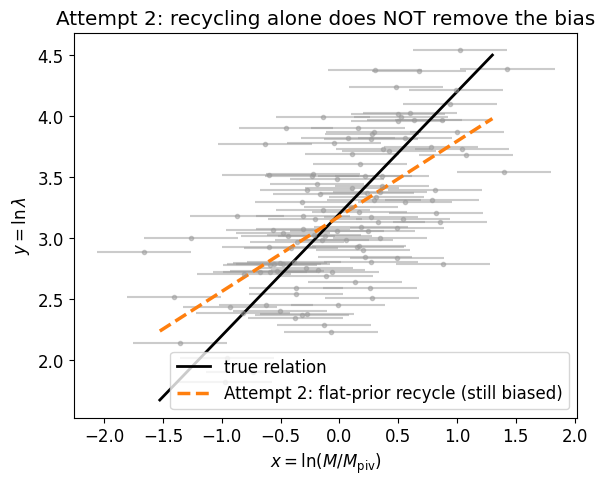

In [6]:
def hyper_logpost_flat(params):
    A, B, log_s = params; s = np.exp(log_s)
    if s > 3: return -np.inf
    tot = 0.0
    for j in range(n_clusters):
        like = np.exp(-0.5*((y_obs[j] - (A + B*wl_samples[j]))/s)**2) / s     # p(richness | mass sample)
        tot += np.log(like.mean() + 1e-300)
    return tot + log_s    # +log_s = Jacobian for sampling in log(sigma)  (=> flat prior on sigma)
chain_flat = run_mcmc(hyper_logpost_flat, start=np.array([A_true, B_true, np.log(sigma_true)]))
A_f, B_f, s_f = chain_flat[:, 0], chain_flat[:, 1], np.exp(chain_flat[:, 2])
print("Attempt 2 (recycle, FLAT prior):  A=%.2f  B=%.2f  sigma=%.3f   <- same biased slope as Attempt 1" % (A_f.mean(), B_f.mean(), s_f.mean()))

plt.figure(figsize=(6.5, 5))
plt.errorbar(x_wl, y_obs, xerr=sigma_WL, fmt="o", ms=3, color="0.6", alpha=0.5)
plt.plot(grid, A_true + B_true*grid, "k-", lw=2, label="true relation")
plt.plot(grid, A_f.mean() + B_f.mean()*grid, "--", color="tab:orange", lw=2.5, label="Attempt 2: flat-prior recycle (still biased)")
plt.xlabel(r"$x=\ln(M/M_{\rm piv})$"); plt.ylabel(r"$y=\ln\lambda$")
plt.title("Attempt 2: recycling alone does NOT remove the bias"); plt.legend(); plt.show()

**Why still biased?** The flat-prior WL samples are symmetric about the noisy estimate $x_j^{\rm WL}$, so
averaging over them *adds variance but recenters nothing* — there is no force pulling up-scattered masses
back down. (This is **not** the same as using the point mass: the extra variance is exactly what attenuates
the slope.) The missing ingredient is the **halo mass function** $p(x)$: up-scattered
low-mass clusters are intrinsically rarer, so their masses must be **shrunk** back. That shrinkage is the
$p(x)/\pi_0$ weight.

## 6. Attempt 3 — recycle **+ the mass function** (the correct calibration)

Put the weight back. With a flat interim prior $\pi_0$, the weight is the **mass distribution**
$p(x_j^{(s)})=\mathcal N(x_j^{(s)};0,\sigma_{\rm mass}^2)$ (the halo mass function folded through selection):
$$\ln\mathcal L(\Lambda)=\sum_j\ln\!\Big[\tfrac1S\sum_s\mathcal N\!\big(y_j;A+Bx_j^{(s)},\sigma^2\big)\,
   \underbrace{\mathcal N\!\big(x_j^{(s)};0,\sigma_{\rm mass}^2\big)}_{p(x)\;=\;\text{mass function}}\Big].$$

   acceptance=0.64 | autocorr ~40 steps | ~2024 independent samples
Attempt 3 (recycle + mass function):  A=3.18±0.04  B=1.03±0.12  sigma=0.317±0.063
                                       -> recovers truth (A=3.20, B=1.00, sigma=0.35)


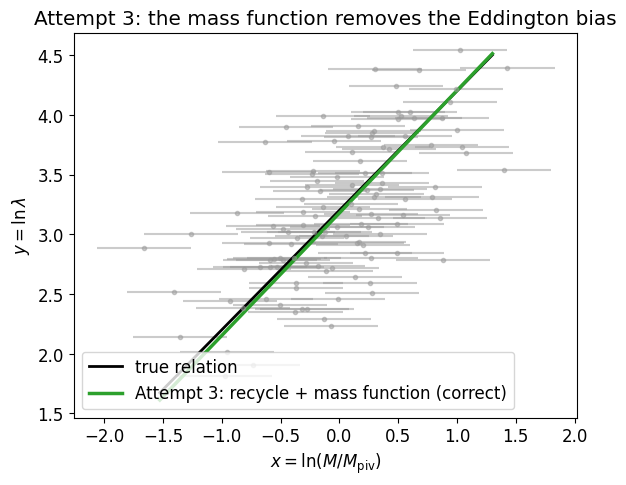

In [7]:
def hyper_logpost_massfunc(params):
    A, B, log_s = params; s = np.exp(log_s)
    if s > 3: return -np.inf
    tot = 0.0
    for j in range(n_clusters):
        like   = np.exp(-0.5*((y_obs[j] - (A + B*wl_samples[j]))/s)**2) / s
        massfn = np.exp(-0.5*(wl_samples[j]/sigma_mass)**2)        # p(x) = halo mass function (the weight)
        tot += np.log((like*massfn).mean() + 1e-300)
    return tot + log_s    # +log_s = Jacobian for sampling in log(sigma)  (=> flat prior on sigma)
chain_mf = run_mcmc(hyper_logpost_massfunc, start=np.array([A_true, B_true, np.log(sigma_true)]))
A_m, B_m, s_m = chain_mf[:, 0], chain_mf[:, 1], np.exp(chain_mf[:, 2])
print("Attempt 3 (recycle + mass function):  A=%.2f±%.2f  B=%.2f±%.2f  sigma=%.3f±%.3f"
      % (A_m.mean(), A_m.std(), B_m.mean(), B_m.std(), s_m.mean(), s_m.std()))
print("                                       -> recovers truth (A=%.2f, B=%.2f, sigma=%.2f)" % (A_true, B_true, sigma_true))

plt.figure(figsize=(6.5, 5))
plt.errorbar(x_wl, y_obs, xerr=sigma_WL, fmt="o", ms=3, color="0.6", alpha=0.5)
plt.plot(grid, A_true + B_true*grid, "k-", lw=2, label="true relation")
plt.plot(grid, A_m.mean() + B_m.mean()*grid, "-", color="tab:green", lw=2.5, label="Attempt 3: recycle + mass function (correct)")
plt.xlabel(r"$x=\ln(M/M_{\rm piv})$"); plt.ylabel(r"$y=\ln\lambda$")
plt.title("Attempt 3: the mass function removes the Eddington bias"); plt.legend(); plt.show()

*(We assumed the mass-function width $\sigma_{\rm mass}$ is **known**. In a real analysis $p(x)$ is the
halo mass function (Tinker et al. 2008) folded through the selection — you would use that directly, or infer
its parameters jointly with $(A,B,\sigma)$.)*

## 7. Summary — the hyper-posterior, and the connection to real analyses

                              A       B       sigma_intr
truth                    :  3.20    1.00    0.350
Attempt 1 naive OLS      :  3.18    0.61    0.450   <- Eddington bias
Attempt 2 flat-recycle   :  3.18    0.62    0.382   <- still biased
Attempt 3 + mass function:  3.18    1.03    0.317   <- correct


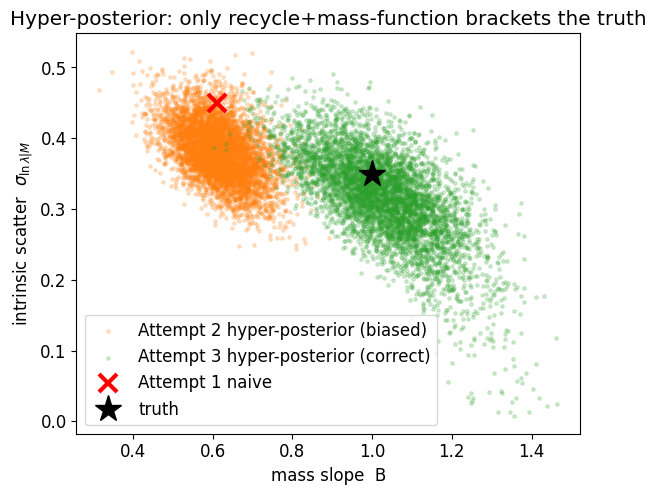

In [8]:
print("                              A       B       sigma_intr")
print("truth                    :  %.2f    %.2f    %.3f" % (A_true, B_true, sigma_true))
print("Attempt 1 naive OLS      :  %.2f    %.2f    %.3f   <- Eddington bias" % (A_naive, B_naive, sigma_naive))
print("Attempt 2 flat-recycle   :  %.2f    %.2f    %.3f   <- still biased" % (A_f.mean(), B_f.mean(), s_f.mean()))
print("Attempt 3 + mass function:  %.2f    %.2f    %.3f   <- correct" % (A_m.mean(), B_m.mean(), s_m.mean()))

# the hyper-posterior on (slope B, intrinsic scatter sigma): truth inside the correct one, not the biased one
plt.figure(figsize=(6.5, 5.2))
plt.scatter(B_f[::15], s_f[::15], s=6, alpha=0.2, color="tab:orange", label="Attempt 2 hyper-posterior (biased)")
plt.scatter(B_m[::15], s_m[::15], s=6, alpha=0.2, color="tab:green", label="Attempt 3 hyper-posterior (correct)")
plt.plot(B_naive, sigma_naive, "rx", ms=13, mew=3, label="Attempt 1 naive")
plt.plot(B_true, sigma_true, "k*", ms=20, label="truth")
plt.xlabel("mass slope  B"); plt.ylabel(r"intrinsic scatter  $\sigma_{\ln\lambda|M}$")
plt.title("Hyper-posterior: only recycle+mass-function brackets the truth"); plt.legend(); plt.show()

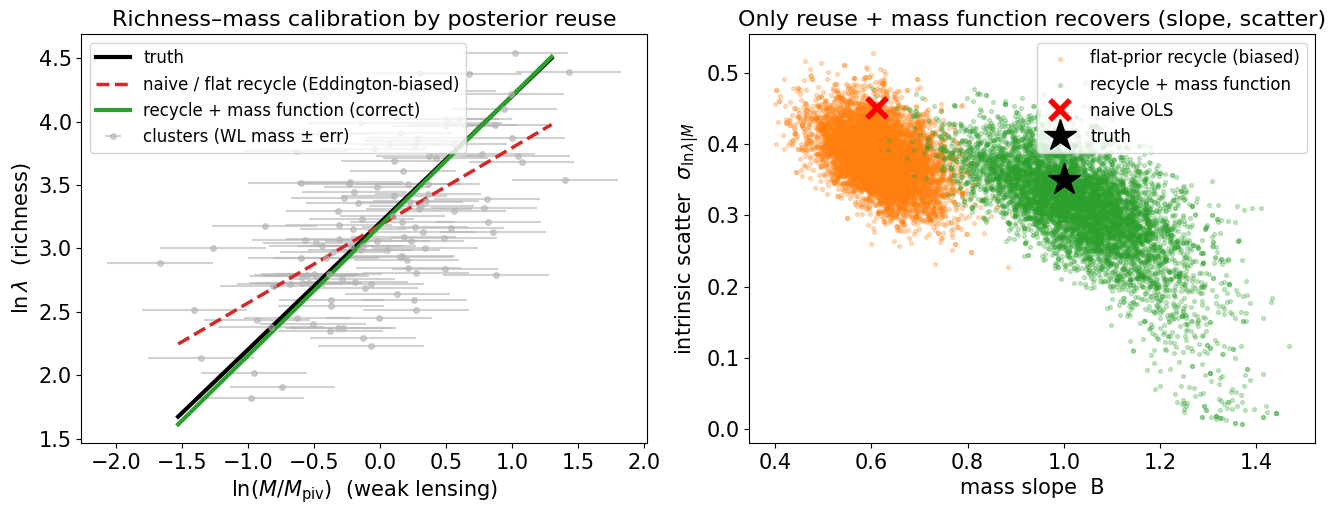

saved -> slide_figures/richness_mass_calibration.png


In [9]:
# --- polished figure for a PROJECT-PITCH SLIDE (saved high-res to slide_figures/) ---
import os; os.makedirs("slide_figures", exist_ok=True)
with plt.rc_context({"font.size": 15, "axes.titlesize": 16, "axes.labelsize": 15, "legend.fontsize": 12,
                     "savefig.dpi": 220, "savefig.bbox": "tight"}):
    fig, ax = plt.subplots(1, 2, figsize=(13.5, 5.4))
    # LEFT: the relation -- data + true + biased + correct
    ax[0].errorbar(x_wl, y_obs, xerr=sigma_WL, fmt="o", ms=4, color="0.7", alpha=0.6, label="clusters (WL mass ± err)")
    ax[0].plot(grid, A_true + B_true*grid, "k-", lw=3, label="truth")
    ax[0].plot(grid, A_naive + B_naive*grid, "--", color="tab:red", lw=2.5, label="naive / flat recycle (Eddington-biased)")
    ax[0].plot(grid, A_m.mean() + B_m.mean()*grid, "-", color="tab:green", lw=3, label="recycle + mass function (correct)")
    ax[0].set_xlabel(r"$\ln(M/M_{\rm piv})$  (weak lensing)"); ax[0].set_ylabel(r"$\ln\lambda$  (richness)")
    ax[0].set_title("Richness–mass calibration by posterior reuse"); ax[0].legend(loc="upper left")
    # RIGHT: the (slope, scatter) hyper-posterior
    ax[1].scatter(B_f[::12], s_f[::12], s=8, alpha=0.25, color="tab:orange", label="flat-prior recycle (biased)")
    ax[1].scatter(B_m[::12], s_m[::12], s=8, alpha=0.25, color="tab:green", label="recycle + mass function")
    ax[1].plot(B_naive, sigma_naive, "rx", ms=15, mew=4, label="naive OLS")
    ax[1].plot(B_true, sigma_true, "k*", ms=24, label="truth")
    ax[1].set_xlabel("mass slope  B"); ax[1].set_ylabel(r"intrinsic scatter  $\sigma_{\ln\lambda|M}$")
    ax[1].set_title("Only reuse + mass function recovers (slope, scatter)"); ax[1].legend(loc="upper right")
    fig.tight_layout(); fig.savefig("slide_figures/richness_mass_calibration.png"); plt.show()
print("saved -> slide_figures/richness_mass_calibration.png")

**Connection to the real pipeline.** The per-cluster `wl_samples[j]` are exactly the **weak-lensing mass
posterior samples** Akum's pipeline produces; $p(x)$ is the **halo mass function (Tinker et al. 2008) folded
through the richness selection** — the ingredients already in `populationutils.py`. With those two swapped
in, the *same* recycling code performs the **mass calibration** of the richness–mass relation $(A,B,\sigma)$,
with **no re-fitting of any cluster**. This is the structure used by e.g. Costanzi et al. 2019, Murata et
al. 2018/2019, and Bocquet et al. 2019/2024 (Bayesian population modeling + a hierarchical per-cluster WL
likelihood).

## 8. Takeaways
1. The population prior can be a full **mass–observable relation** (normalization, slope, **intrinsic
   scatter**), and what we infer is its **hyper-posterior**.
2. **Recycling** per-cluster WL posteriors infers it cheaply — *but* with a **flat** mass prior it keeps the
   **Eddington bias** (slope too shallow, scatter too large).
3. Re-weighting by the **halo mass function** $p(x)/\pi_0$ removes the bias and recovers the truth.

*Same principle as Tutorial 1 — **shrinkage**: the population prior pulls noisy individual estimates toward
where clusters actually live (see the "one idea, three faces" box in Tutorial 1).*

## 9. Try it yourself
- Comment out the `massfn` weight in Attempt 3 — you recover Attempt 2's biased slope.
- Raise `sigma_WL` toward `sigma_mass` — the naive/flat bias gets worse (attenuation $\to 0.5$); does
  Attempt 3 still recover $B$?
- Make `sigma_mass` very large (a nearly flat mass function) — why does the bias vanish even for Attempt 2?
- Replace the Gaussian `massfn` with a falling exponential $e^{-\alpha x}$ (a crude mass function) — the
  Eddington correction becomes *directional* (shrinks high masses more), as in real clusters.